## Imports ##

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import scipy.constants

## Plot Ionizing Radiation (Figure 2) ##

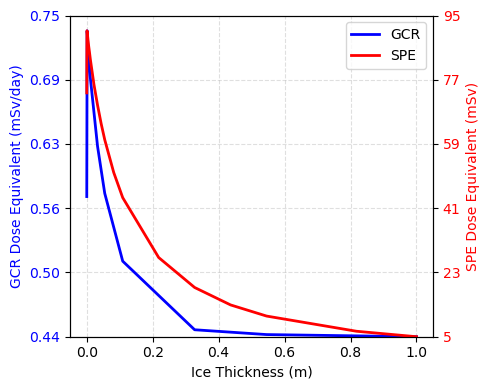

In [6]:
file_path_gcr = "your file location here/gcr-dose-equivalent.csv"
file_path_spe = "your file location here/spe-dose-equivalent.csv"

rad_attn_gcr_pd = pd.read_csv(file_path_gcr)
rad_attn_spe_pd = pd.read_csv(file_path_spe)

fig, ax1 = plt.subplots(figsize=(5, 4))

# GCR — left y-axis

gcr_line = ax1.plot(
    rad_attn_gcr_pd["Sphere Thickness (g/cm2)"] / 91.7, # convert density to ice thickness
    rad_attn_gcr_pd["Series 1"], # GCR dose equivalent
    color="blue",
    linewidth=2,
    label="GCR"
)

ax1.set_xlabel("Ice Thickness (m)")
ax1.set_ylabel("GCR Dose Equivalent (mSv/day)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# SPE — right y-axis

ax2 = ax1.twinx()

spe_line = ax2.plot(
    rad_attn_spe_pd["Sphere Thickness (g/cm2)"] / 91.7, # convert density to ice thickness
    rad_attn_spe_pd["Series 1"], # SPE dose equivalent
    color="red",
    linewidth=2,
    label="SPE"
)

ax2.set_ylabel("SPE Dose Equivalent (mSv)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Get data ranges

gcr_min = rad_attn_gcr_pd["Series 1"].min()
gcr_max = rad_attn_gcr_pd["Series 1"].max()

spe_min = rad_attn_spe_pd["Series 1"].min()
spe_max = rad_attn_spe_pd["Series 1"].max()

# Set identical relative y-axis scaling

# Add a small amount of space above the maximum
gcr_top = gcr_max + 0.05 * (gcr_max - gcr_min)
spe_top = spe_max + 0.05 * (spe_max - spe_min)

ax1.set_ylim(gcr_min, gcr_top)
ax2.set_ylim(spe_min, spe_top)

# Set same number of ticks on both axes
n_ticks = 6

gcr_ticks = np.linspace(gcr_min, gcr_top, n_ticks)
spe_ticks = np.linspace(spe_min, spe_top, n_ticks)

ax1.set_yticks(gcr_ticks)
ax2.set_yticks(spe_ticks)

# Format tick labels
ax1.set_yticklabels([f"{x:.2f}" for x in gcr_ticks])
ax2.set_yticklabels([f"{x:.0f}" for x in spe_ticks])

# Grid lines now correspond exactly to both axes
ax1.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.4
)

# Combined legend

lines = gcr_line + spe_line
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels)

plt.tight_layout()

plt.show()